# Amatrice Result Explorer

Compact overview of explicitly selected result grids for legacy validation, `a_training + validation`, and `training + test`.


In [6]:
from pathlib import Path
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import ScalarFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable

from functions.result_paths import list_available_runs, resolve_run_dir

mpl.rcParams.update({
    'figure.figsize': (7.2, 4.8),
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'regular',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'font.size': 10,
    'grid.alpha': 0.15,
    'legend.frameon': False,
})

ACCENT = '#355c7d'
DARK = '#222222'
LIGHT = '#f3efe8'


In [8]:
WORKFLOW_ORDER = (
    'pretraining',
    'legacy_validation',
    'validation',
    'training',
    'test',
)
WORKFLOW_LABELS = {
    'pretraining': 'pretraining',
    'legacy_validation': 'legacy validation',
    'validation': 'validation',
    'training': 'training',
    'test': 'test',
}
N_TIME_LIST = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
TRAIN_SPACE_LIST = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
EVAL_SPACE_LIST = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
AVAILABLE_RUNS = {
    workflow: list_available_runs(workflow)
    for workflow in WORKFLOW_ORDER
}


RUN_SELECTION = {
    # Set these explicitly when you want to compare a specific run.
    'pretraining': '20260504',
    'legacy_validation': '20260504',
    'validation': '20260505',
    'training': '20260504',
    'test': '20260505',
}


RUN_DIRS = {
    workflow: resolve_run_dir(workflow, RUN_SELECTION[workflow])
    for workflow in WORKFLOW_ORDER
}

display(pd.DataFrame([
    {
        'workflow': WORKFLOW_LABELS[workflow],
        'run_name': RUN_SELECTION[workflow],
        'available_runs': ', '.join(AVAILABLE_RUNS[workflow]),
        'folder': str(RUN_DIRS[workflow]),
    }
    for workflow in WORKFLOW_ORDER
]))


,workflow,run_name,available_runs,folder
0,pretraining,20260504,20260504,/Users/aron/polybox/Projects/b_amatrice/result...
1,legacy validation,20260504,20260504,/Users/aron/polybox/Projects/b_amatrice/result...
2,validation,20260505,"20260504, 20260505",/Users/aron/polybox/Projects/b_amatrice/result...
3,training,20260504,20260504,/Users/aron/polybox/Projects/b_amatrice/result...
4,test,20260505,"20260504, 20260505",/Users/aron/polybox/Projects/b_amatrice/result...


In [9]:
FILE_RE = re.compile(r'(?P<prefix>train|valid|test)_n_time(?P<n_time>\d+)_n_space(?P<n_space>\d+)\.csv')


def load_results(folder: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(folder.glob('*.csv')):
        match = FILE_RE.fullmatch(path.name)
        if not match:
            continue
        record = pd.read_csv(path).iloc[0].to_dict()
        record['n_time'] = int(match['n_time'])
        record['n_space'] = int(match['n_space'])
        record['file'] = path.name
        rows.append(record)
    if not rows:
        return pd.DataFrame(columns=['n_time', 'n_space'])
    return pd.DataFrame(rows).sort_values(['n_time', 'n_space']).reset_index(drop=True)


def add_training_metrics(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in ['mac', 'mu_mac', 'std_mac']:
        if col not in out.columns:
            out[col] = np.nan
    out['spatial_z'] = (out['mac'] - out['mu_mac']) / out['std_mac'].replace(0, np.nan)
    out['spatial_significant'] = out['spatial_z'] > 1.96
    return out


def add_eval_metrics(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in ['IG_classic', 'IG_positive', 'p_classic', 'p_positive', 'IG_classic_norm', 'IG_positive_norm']:
        if col not in out.columns:
            out[col] = np.nan
    out['classic_significant'] = out['p_classic'] < 0.05
    out['positive_significant'] = out['p_positive'] < 0.05
    return out


def pivot_metric(df: pd.DataFrame, value_col: str, spaces: list[int]) -> pd.DataFrame:
    table = df.pivot(index='n_time', columns='n_space', values=value_col)
    return table.reindex(index=N_TIME_LIST, columns=spaces)


def coverage_table(df: pd.DataFrame, spaces: list[int]) -> pd.DataFrame:
    base = pd.MultiIndex.from_product([N_TIME_LIST, spaces], names=['n_time', 'n_space']).to_frame(index=False)
    base['available'] = base.set_index(['n_time', 'n_space']).index.isin(df.set_index(['n_time', 'n_space']).index)
    return pivot_metric(base, 'available', spaces)


def scale_lookup(df: pd.DataFrame, axis_col: str, scale_col: str) -> dict[int, float]:
    if df.empty or scale_col not in df.columns:
        return {}
    clean = df[[axis_col, scale_col]].dropna()
    if clean.empty:
        return {}
    return clean.groupby(axis_col)[scale_col].median().to_dict()


def format_scale(value: float) -> str:
    if value >= 100:
        return f'{value:.0f}'
    if value >= 10:
        return f'{value:.1f}'
    return f'{value:.2f}'


def scale_labels(values, scale_map: dict[int, float] | None) -> list[str]:
    labels = []
    for value in values:
        scale = None if not scale_map else scale_map.get(int(value))
        labels.append('' if scale is None or pd.isna(scale) else format_scale(float(scale)))
    return labels


def style_axis_ticks(ax, table: pd.DataFrame, x_scale_map=None, y_scale_map=None):
    x_values = np.asarray(table.columns, dtype=float)
    y_values = np.asarray(table.index, dtype=float)
    x_labels = scale_labels(table.columns, x_scale_map)
    y_labels = scale_labels(table.index, y_scale_map)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks(x_values)
    ax.set_yticks(y_values)
    ax.set_xticklabels(x_labels, rotation=45, va='top', ha='right')
    ax.set_yticklabels(y_labels)
    ax.tick_params(axis='both', labelsize=8)
    ax.minorticks_off()

    if not any(x_labels):
        ax.tick_params(axis='x', length=0)
    if not any(y_labels):
        ax.tick_params(axis='y', length=0)


def style_colorbar(cbar, label: str, data: np.ndarray):
    cbar.set_label(label)
    cbar.outline.set_linewidth(0.6)
    finite = np.asarray(data, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size and np.nanmax(np.abs(finite)) < 0.05 and not np.all(np.isin(np.unique(finite), [0.0, 1.0])):
        cbar.formatter = ScalarFormatter(useMathText=True)
        cbar.formatter.set_scientific(True)
        cbar.formatter.set_powerlimits((0, 0))
        cbar.update_ticks()


def log_edges(values: np.ndarray) -> np.ndarray:
    ratios = np.sqrt(values[1:] / values[:-1])
    return np.concatenate(([values[0] / ratios[0]], values[:-1] * ratios, [values[-1] * ratios[-1]]))


def resolve_diverging_norm(data: np.ma.MaskedArray, cmap, vmin=None, vmax=None):
    if cmap != 'coolwarm':
        return None, vmin, vmax

    finite = np.asarray(data, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return None, vmin, vmax

    if vmin is None and vmax is None:
        bound = np.nanmax(np.abs(finite))
        if not np.isfinite(bound) or bound == 0:
            bound = 1.0
        vmin, vmax = -bound, bound
    elif vmin is None:
        vmin = float(np.nanmin(finite))
    elif vmax is None:
        vmax = float(np.nanmax(finite))

    if vmin == vmax:
        bound = abs(vmin) if vmin != 0 else 1.0
        vmin, vmax = -bound, bound

    return mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax), None, None


def restyle_best_marker(ax, inner_size=65):
    return ax


def draw_heatmap(
    ax,
    table: pd.DataFrame,
    title: str,
    label: str,
    *,
    cmap='plasma',
    vmin=None,
    vmax=None,
    significant=None,
    best=None,
    x_scale_map=None,
    y_scale_map=None,
):
    x_values = np.asarray(table.columns, dtype=float)
    y_values = np.asarray(table.index, dtype=float)
    data = np.ma.masked_invalid(table.to_numpy(dtype=float))
    cmap_obj = mpl.colormaps[cmap].copy() if isinstance(cmap, str) else cmap.copy()
    cmap_obj.set_bad(LIGHT)
    norm, vmin, vmax = resolve_diverging_norm(data, cmap, vmin=vmin, vmax=vmax)
    x_edges, y_edges = np.meshgrid(log_edges(x_values), log_edges(y_values))

    im = ax.pcolormesh(
        x_edges,
        y_edges,
        data,
        cmap=cmap_obj,
        norm=norm,
        shading='auto',
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_facecolor(LIGHT)
    ax.set_xlabel('length-scale [km]')
    ax.set_ylabel('time-scale [days]')
    ax.set_title(title)
    ax.grid(False)
    style_axis_ticks(ax, table, x_scale_map=x_scale_map, y_scale_map=y_scale_map)

    if significant is not None:
        sig = significant.reindex(index=table.index, columns=table.columns).eq(True).to_numpy(dtype=bool)
        iy, ix = np.where(sig)
        if len(ix):
            ax.scatter(x_values[ix], y_values[iy], color='white', s=15, zorder=4)

    if best is not None and not best.empty:
        if int(best['n_space']) in table.columns and int(best['n_time']) in table.index:
            ax.scatter(float(best['n_space']), float(best['n_time']), color='black', s=18, zorder=5)

    if data.count() == 0:
        ax.text(
            0.5,
            0.5,
            'no results available',
            transform=ax.transAxes,
            ha='center',
            va='center',
            fontsize=11,
            color=DARK,
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.88, 'boxstyle': 'round,pad=0.35'},
            zorder=6,
        )

    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
    style_colorbar(cbar, label, table.to_numpy(dtype=float))
    return im


def best_row(df: pd.DataFrame, score_col: str, *, significant_col: str | None = None) -> pd.Series | None:
    ranked = df.copy()
    if significant_col is not None:
        ranked = ranked[ranked[significant_col].fillna(False)]
    ranked = ranked.dropna(subset=[score_col])
    if ranked.empty:
        return None
    return ranked.sort_values(score_col, ascending=False).iloc[0]


def make_panel(df: pd.DataFrame, title: str, label: str, metric: str, *, scale_key: str, cmap: str, sig_col: str | None = None, spaces: list[int] | None = None) -> dict:
    return {
        'df': df,
        'title': title,
        'label': label,
        'metric': metric,
        'sig_col': sig_col,
        'scale_key': scale_key,
        'cmap': cmap,
        'spaces': TRAIN_SPACE_LIST if spaces is None and metric == 'mac' else (EVAL_SPACE_LIST if spaces is None else spaces),
    }


def render_panel_group(title: str, panels: list[dict], *, figsize: tuple[float, float], shared_spaces: list[int] | None = None):
    fig, axes = plt.subplots(1, len(panels), figsize=figsize)
    axes = np.atleast_1d(axes)
    fig.set_facecolor('white')
    fig.suptitle(title, fontsize=16)

    for ax, panel in zip(axes, panels):
        spaces = panel['spaces'] if shared_spaces is None else shared_spaces
        draw_heatmap(
            ax,
            pivot_metric(panel['df'], panel['metric'], spaces),
            panel['title'],
            panel['label'],
            cmap=panel['cmap'],
            significant=None if panel['sig_col'] is None else pivot_metric(panel['df'], panel['sig_col'], spaces),
            best=best_row(panel['df'], panel['metric'], significant_col=panel['sig_col']),
            x_scale_map=scale_maps[panel['scale_key']]['x'],
            y_scale_map=scale_maps[panel['scale_key']]['y'],
        )

    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()


def best_summary_row(workflow: str, panel: str, df: pd.DataFrame, score_col: str, *, scale_key: str, support_col: str | None = None, significant_col: str | None = None) -> dict:
    row = best_row(df, score_col, significant_col=significant_col)
    result = {
        'workflow': workflow,
        'panel': panel,
        'score': np.nan,
        'support': np.nan,
        'n_time': np.nan,
        'n_space': np.nan,
        'time_scale_days': np.nan,
        'length_scale_km': np.nan,
    }
    if row is None:
        return result
    result.update({
        'score': row.get(score_col, np.nan),
        'support': row.get(support_col, np.nan) if support_col else np.nan,
        'n_time': int(row['n_time']),
        'n_space': int(row['n_space']),
        'time_scale_days': scale_maps[scale_key]['y'].get(int(row['n_time']), np.nan),
        'length_scale_km': scale_maps[scale_key]['x'].get(int(row['n_space']), np.nan),
    })
    return result


In [10]:
DATASET_PREPARERS = {
    'pretraining': add_training_metrics,
    'legacy_validation': add_eval_metrics,
    'validation': add_eval_metrics,
    'training': add_training_metrics,
    'test': add_eval_metrics,
}

result_data = {
    workflow: DATASET_PREPARERS[workflow](load_results(RUN_DIRS[workflow]))
    for workflow in WORKFLOW_ORDER
}
scale_maps = {
    workflow: {
        'x': scale_lookup(df, 'n_space', 's_scale'),
        'y': scale_lookup(df, 'n_time', 't_scale'),
    }
    for workflow, df in result_data.items()
}

pretraining_df = result_data['pretraining']
legacy_validation_df = result_data['legacy_validation']
validation_df = result_data['validation']
training_df = result_data['training']
test_df = result_data['test']

summary = pd.DataFrame([
    {
        'dataset': WORKFLOW_LABELS[workflow],
        'run_name': RUN_SELECTION[workflow],
        'rows': len(result_data[workflow]),
        'n_time values': result_data[workflow]['n_time'].nunique(),
        'n_space values': result_data[workflow]['n_space'].nunique(),
    }
    for workflow in WORKFLOW_ORDER
])

display(summary)


,dataset,run_name,rows,n_time values,n_space values
0,pretraining,20260504,120,10,12
1,legacy validation,20260504,0,0,0
2,validation,20260505,4,1,4
3,training,20260504,113,10,12
4,test,20260505,3,1,3


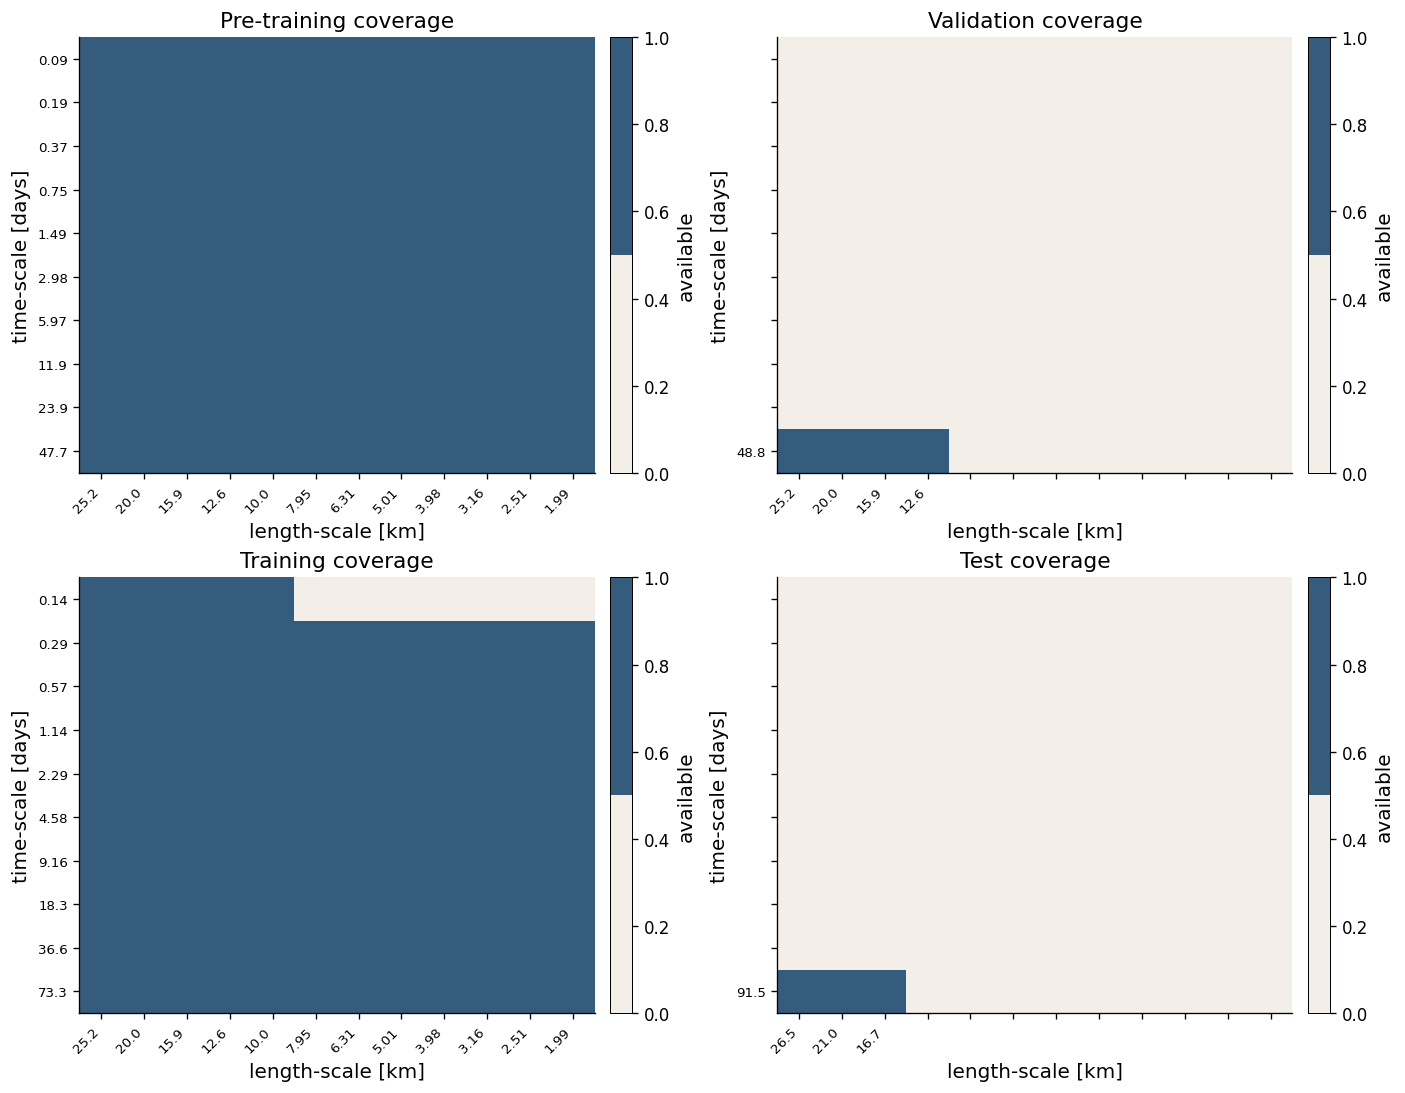

In [11]:
coverage_cmap = mpl.colors.ListedColormap([LIGHT, ACCENT])
fig, axes = plt.subplots(2, 2, figsize=(11.6, 9.0), constrained_layout=True)

for ax, df, title, spaces, scale_key in [
    (axes[0, 0], pretraining_df, 'Pre-training coverage', TRAIN_SPACE_LIST, 'pretraining'),
    (axes[0, 1], validation_df, 'Validation coverage', EVAL_SPACE_LIST, 'validation'),
    (axes[1, 0], training_df, 'Training coverage', TRAIN_SPACE_LIST, 'training'),
    (axes[1, 1], test_df, 'Test coverage', EVAL_SPACE_LIST, 'test'),
]:
    draw_heatmap(
        ax,
        coverage_table(df, spaces),
        title,
        'available',
        cmap=coverage_cmap,
        vmin=0,
        vmax=1,
        x_scale_map=scale_maps[scale_key]['x'],
        y_scale_map=scale_maps[scale_key]['y'],
    )

plt.show()


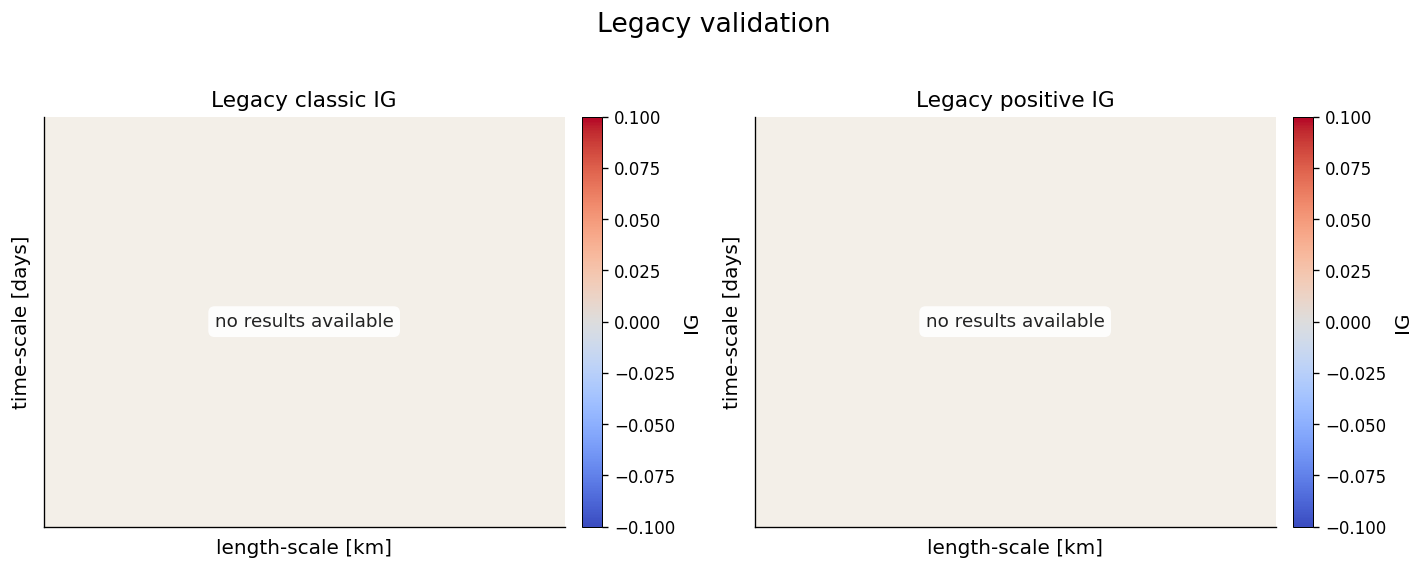

In [14]:
panel_groups = [
        (
        'Legacy validation',
        [
            make_panel(legacy_validation_df, 'Legacy classic IG', 'IG', 'IG_classic', scale_key='legacy_validation', sig_col='classic_significant', cmap='coolwarm'),
            make_panel(legacy_validation_df, 'Legacy positive IG', 'IG', 'IG_positive', scale_key='legacy_validation', sig_col='positive_significant', cmap='coolwarm'),
        ],
        (12.0, 4.8),
        EVAL_SPACE_LIST,
    ),
    ]

for title, panels, figsize, shared_spaces in panel_groups:
    render_panel_group(title, panels, figsize=figsize, shared_spaces=shared_spaces)


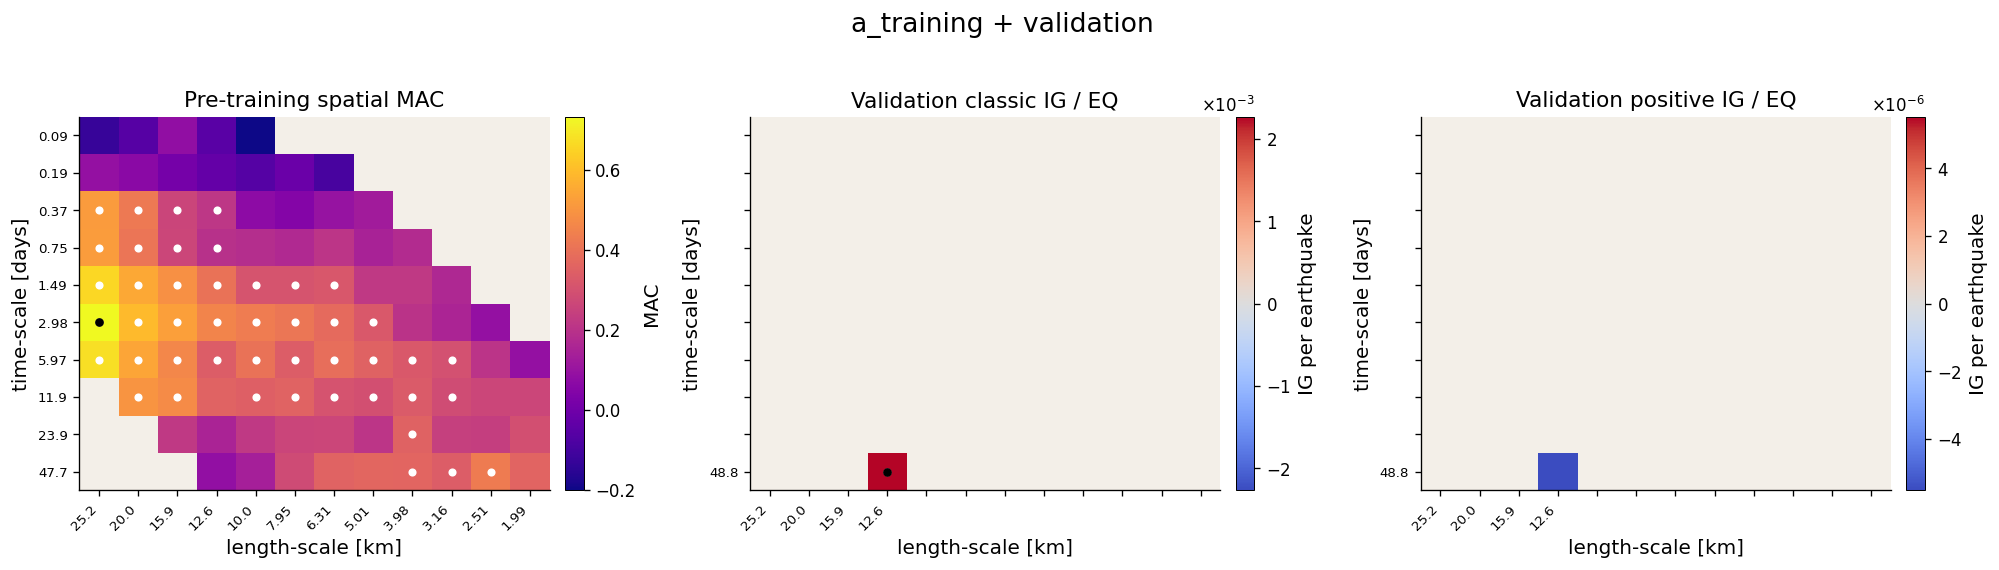

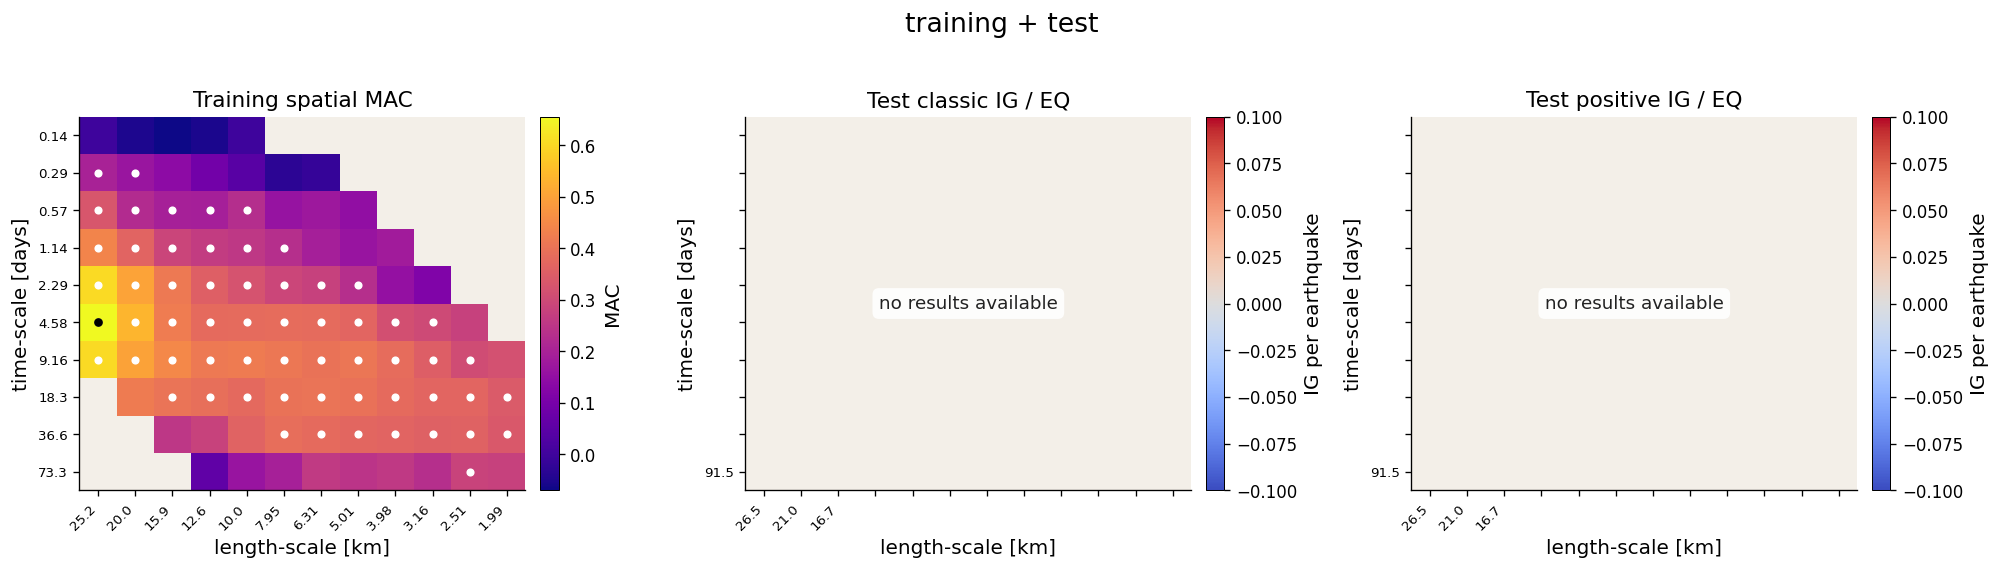

In [13]:
panel_groups = [
    (
        'a_training + validation',
        [
            make_panel(pretraining_df, 'Pre-training spatial MAC', 'MAC', 'mac', scale_key='pretraining', sig_col='spatial_significant', cmap='plasma'),
            make_panel(validation_df, 'Validation classic IG / EQ', 'IG per earthquake', 'IG_classic_norm', scale_key='validation', sig_col='classic_significant', cmap='coolwarm'),
            make_panel(validation_df, 'Validation positive IG / EQ', 'IG per earthquake', 'IG_positive_norm', scale_key='validation', sig_col='positive_significant', cmap='coolwarm'),
        ],
        (16.8, 4.8),
        TRAIN_SPACE_LIST,
    ),
    (
        'training + test',
        [
            make_panel(training_df, 'Training spatial MAC', 'MAC', 'mac', scale_key='training', sig_col='spatial_significant', cmap='plasma'),
            make_panel(test_df, 'Test classic IG / EQ', 'IG per earthquake', 'IG_classic_norm', scale_key='test', sig_col='classic_significant', cmap='coolwarm'),
            make_panel(test_df, 'Test positive IG / EQ', 'IG per earthquake', 'IG_positive_norm', scale_key='test', sig_col='positive_significant', cmap='coolwarm'),
        ],
        (16.8, 4.8),
        TRAIN_SPACE_LIST,
    ),
]

for title, panels, figsize, shared_spaces in panel_groups:
    render_panel_group(title, panels, figsize=figsize, shared_spaces=shared_spaces)


In [51]:
best_summary = pd.DataFrame([
    best_summary_row('legacy validation', 'classic IG', legacy_validation_df, 'IG_classic', scale_key='legacy_validation', support_col='p_classic', significant_col='classic_significant'),
    best_summary_row('legacy validation', 'positive IG', legacy_validation_df, 'IG_positive', scale_key='legacy_validation', support_col='p_positive', significant_col='positive_significant'),
    best_summary_row('a_training + validation', 'pre-training spatial MAC', pretraining_df, 'mac', scale_key='pretraining', support_col='spatial_z', significant_col='spatial_significant'),
    best_summary_row('a_training + validation', 'validation classic IG / EQ', validation_df, 'IG_classic_norm', scale_key='validation', support_col='p_classic', significant_col='classic_significant'),
    best_summary_row('a_training + validation', 'validation positive IG / EQ', validation_df, 'IG_positive_norm', scale_key='validation', support_col='p_positive', significant_col='positive_significant'),
    best_summary_row('training + test', 'training spatial MAC', training_df, 'mac', scale_key='training', support_col='spatial_z', significant_col='spatial_significant'),
    best_summary_row('training + test', 'test classic IG / EQ', test_df, 'IG_classic_norm', scale_key='test', support_col='p_classic', significant_col='classic_significant'),
    best_summary_row('training + test', 'test positive IG / EQ', test_df, 'IG_positive_norm', scale_key='test', support_col='p_positive', significant_col='positive_significant'),
])

display(best_summary.round({'score': 6, 'support': 6, 'time_scale_days': 3, 'length_scale_km': 3}))


,workflow,panel,score,support,n_time,n_space,time_scale_days,length_scale_km
0,legacy validation,classic IG,NaN,NaN,NaN,NaN,NaN,NaN
1,legacy validation,positive IG,NaN,NaN,NaN,NaN,NaN,NaN
2,a_training + validation,pre-training spatial MAC,0.732880,4.113135,32.0,1.0,2.983,25.249
3,a_training + validation,validation classic IG / EQ,NaN,NaN,NaN,NaN,NaN,NaN
4,a_training + validation,validation positive IG / EQ,NaN,NaN,NaN,NaN,NaN,NaN
5,training + test,training spatial MAC,0.654888,3.755090,32.0,1.0,4.580,25.250
6,training + test,test classic IG / EQ,NaN,NaN,NaN,NaN,NaN,NaN
7,training + test,test positive IG / EQ,NaN,NaN,NaN,NaN,NaN,NaN
